# Milestone 2: Draft White Paper Analysis

## 1. Load and Inspect Data

In [84]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [85]:
# Load the dataset

df = pd.read_csv("C:/Users/Allis/Downloads/who_alcohol_total_per_capita_2000_2022_clean.csv")
df.head()

,country,iso3,year,sex,alcohol_liters_per_capita,lower_ci,upper_ci,ci_width,IndicatorCode
0,Italy,ITA,2003,Both sexes,9.622988,7.965011,11.388622,3.423611,SA_0000001688
1,"Tanzania, United Republic of",TZA,2006,Both sexes,6.337646,4.767623,8.109324,3.341701,SA_0000001688
2,Cyprus,CYP,2017,Both sexes,6.117152,4.627244,7.798063,3.170819,SA_0000001688
3,Sierra Leone,SLE,2019,Both sexes,0.253228,0.100851,0.567434,0.466583,SA_0000001688
4,Philippines,PHL,2017,Both sexes,6.023875,4.681733,7.536645,2.854912,SA_0000001688


## 2. Data Cleaning

In [87]:
# Check column names

df.columns

Index(['country', 'iso3', 'year', 'sex', 'alcohol_liters_per_capita',
       'lower_ci', 'upper_ci', 'ci_width', 'IndicatorCode'],
      dtype='object')

In [88]:
# Rename columns if needed

df = df.rename(columns={
    'country': 'Country',
    'year': 'Year',
    'alcohol_liters_per_capita': 'Alcohol_Consumption'
})

In [89]:
# Basic cleaning

df = df[['Country', 'Year', 'Alcohol_Consumption']].copy()

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Alcohol_Consumption'] = pd.to_numeric(df['Alcohol_Consumption'], errors='coerce')

df = df.dropna(subset=['Country', 'Year', 'Alcohol_Consumption'])
df['Country'] = df['Country'].str.strip()

df.head()

,Country,Year,Alcohol_Consumption
0,Italy,2003,9.622988
1,"Tanzania, United Republic of",2006,6.337646
2,Cyprus,2017,6.117152
3,Sierra Leone,2019,0.253228
4,Philippines,2017,6.023875


## 3. Exploratory Data Analysis

In [91]:
# Basic dataset overview

print("Number of rows:", df.shape[0])
print("Number of countries:", df['Country'].nunique())
print("Year range:", int(df['Year'].min()), "to", int(df['Year'].max()))

Number of rows: 4324
Number of countries: 188
Year range: 2000 to 2022


## 4. Trend Analysis

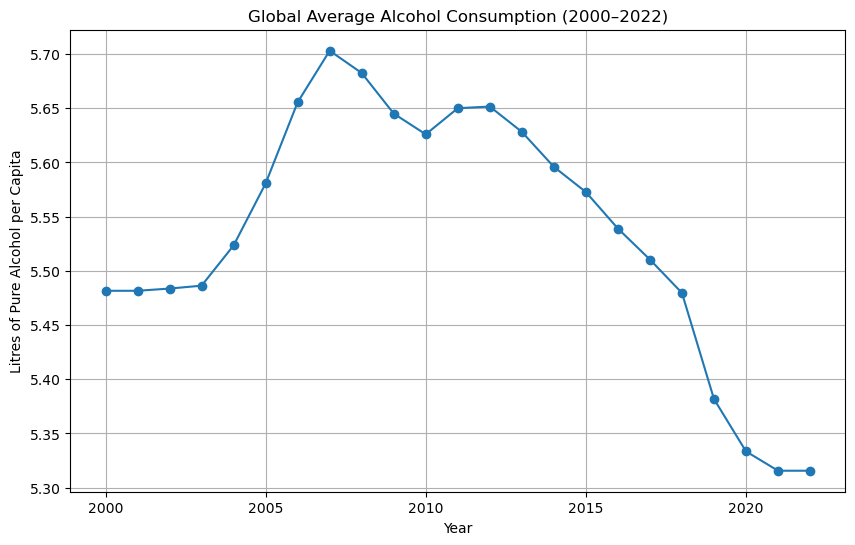

In [93]:
# Illustration 1: Global average alcohol consumption trend

global_trend = df.groupby('Year')['Alcohol_Consumption'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(global_trend['Year'], global_trend['Alcohol_Consumption'], marker='o')
plt.title('Global Average Alcohol Consumption (2000–2022)')
plt.xlabel('Year')
plt.ylabel('Litres of Pure Alcohol per Capita')
plt.grid(True)
plt.savefig('global_average_alcohol_consumption.png', bbox_inches='tight')
plt.show()

In [94]:
# Illustration 2: Top 10 countries with the largest increase from 2000 to 2022

trend_compare = df[df['Year'].isin([2000, 2022])].pivot_table(
    index='Country',
    columns='Year',
    values='Alcohol_Consumption'
).dropna()

trend_compare['Increase'] = trend_compare[2022] - trend_compare[2000]
top_10_increase = trend_compare.sort_values('Increase', ascending=False).head(10)

top_10_increase

Year,2000,2022,Increase
Country,,,
Viet Nam,4.046239,10.715408,6.669169
Mongolia,2.760842,7.735525,4.974683
"Moldova, Republic of",9.452002,14.128274,4.676273
Cambodia,0.871514,5.398220,4.526706
Congo,2.718459,6.351449,3.632990
Latvia,11.100823,14.725691,3.624868
Georgia,12.362885,15.538821,3.175937
Estonia,7.612215,10.487442,2.875227
Namibia,9.167580,11.993195,2.825615


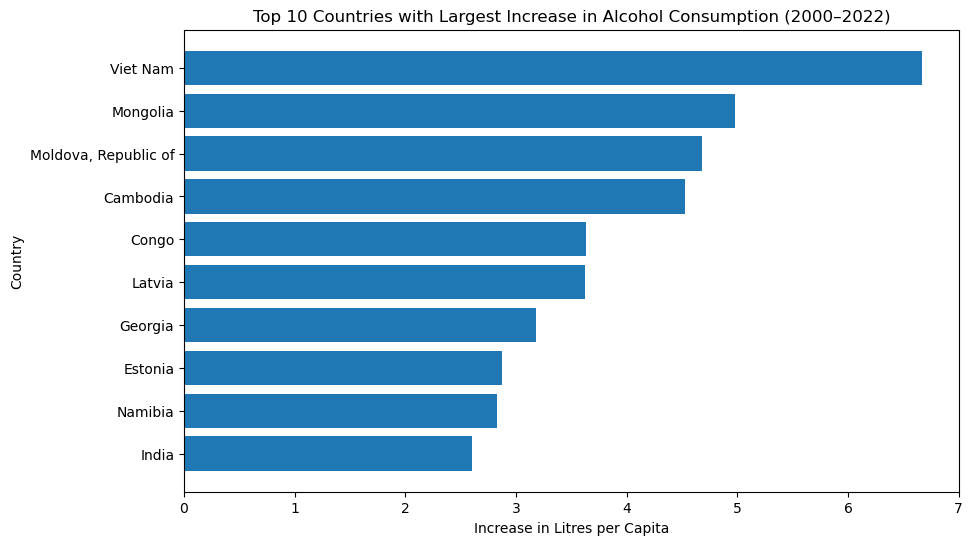

In [95]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_increase.index, top_10_increase['Increase'])
plt.title('Top 10 Countries with Largest Increase in Alcohol Consumption (2000–2022)')
plt.xlabel('Increase in Litres per Capita')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.savefig('top_10_countries_alc_con.png', bbox_inches='tight')
plt.show()

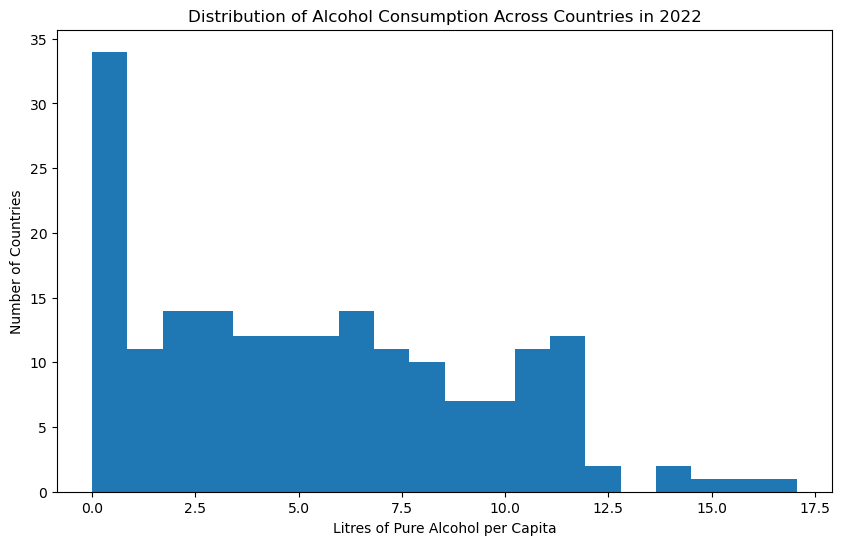

In [96]:
# Illustration 3: Distribution of alcohol consumption in 2022

df_2022 = df[df['Year'] == 2022]

plt.figure(figsize=(10, 6))
plt.hist(df_2022['Alcohol_Consumption'], bins=20)
plt.title('Distribution of Alcohol Consumption Across Countries in 2022')
plt.xlabel('Litres of Pure Alcohol per Capita')
plt.ylabel('Number of Countries')
plt.savefig('alc_con_distribution.png', bbox_inches='tight')
plt.show()

## 5. Clustering Countries by Trend Profile

In [98]:
# Create trend features for clustering

country_features = []

for country, group in df.groupby('Country'):
    group = group.sort_values('Year')
    
    if group['Year'].nunique() < 8:
        continue
    
    x = group['Year']
    y = group['Alcohol_Consumption']
    
    slope = np.polyfit(x, y, 1)[0]
    avg_level = y.mean()
    volatility = y.std()
    
    early_avg = group[group['Year'] <= 2005]['Alcohol_Consumption'].mean()
    late_avg = group[group['Year'] >= 2017]['Alcohol_Consumption'].mean()
    change_period = late_avg - early_avg
    
    country_features.append([country, avg_level, slope, volatility, change_period])

features_df = pd.DataFrame(country_features, columns=[
    'Country', 'Avg_Level', 'Slope', 'Volatility', 'Change_Period'
])

features_df.head()

,Country,Avg_Level,Slope,Volatility,Change_Period
0,Afghanistan,0.015476,0.000178,0.007584,0.003243
1,Albania,5.337663,-0.030707,0.455387,-0.334549
2,Algeria,0.477417,0.003694,0.044897,0.050646
3,Andorra,11.958346,-0.110033,0.869068,-1.795495
4,Angola,6.740655,-0.053283,1.472944,-0.990525


In [99]:
# Illustration 4: Clustering countries by trend profile

X = features_df[['Avg_Level', 'Slope', 'Volatility', 'Change_Period']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
features_df['Cluster'] = kmeans.fit_predict(X_scaled)

features_df.head()

C:\Users\Allis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



,Country,Avg_Level,Slope,Volatility,Change_Period,Cluster
0,Afghanistan,0.015476,0.000178,0.007584,0.003243,0
1,Albania,5.337663,-0.030707,0.455387,-0.334549,0
2,Algeria,0.477417,0.003694,0.044897,0.050646,0
3,Andorra,11.958346,-0.110033,0.869068,-1.795495,1
4,Angola,6.740655,-0.053283,1.472944,-0.990525,1


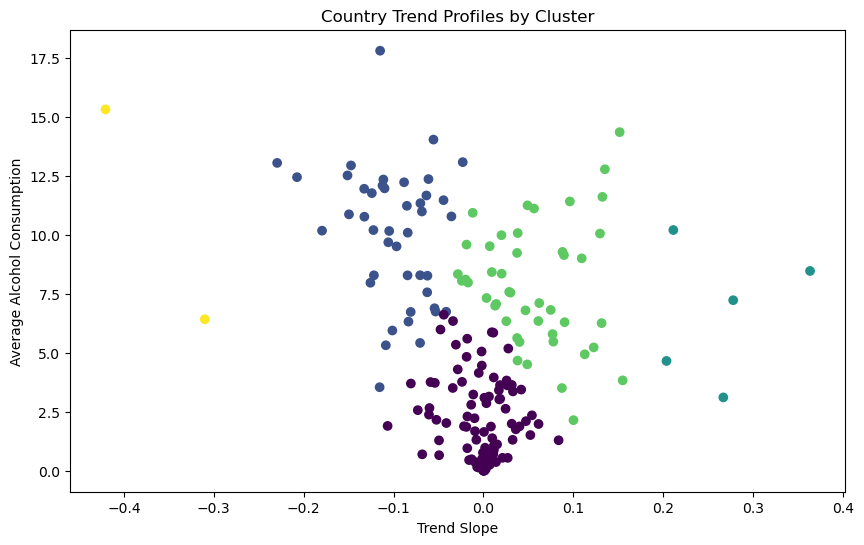

In [100]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(features_df['Slope'], features_df['Avg_Level'], c=features_df['Cluster'])
plt.title('Country Trend Profiles by Cluster')
plt.xlabel('Trend Slope')
plt.ylabel('Average Alcohol Consumption')
plt.savefig('country_trend_profiles.png', bbox_inches='tight')
plt.show()

In [101]:
# Look at cluster sizes

features_df['Cluster'].value_counts().sort_index()

Cluster
0    93
1    43
2     5
3    45
4     2
Name: count, dtype: int64

## 6. Forecasting Example

In [103]:
# Illustration 5: Forecast for one country

country_name = "United States"

country_data = df[df['Country'] == country_name].sort_values('Year')

x = country_data['Year']
y = country_data['Alcohol_Consumption']

m, b = np.polyfit(x, y, 1)

future_years = np.arange(x.min(), x.max() + 6)
forecast_values = m * future_years + b

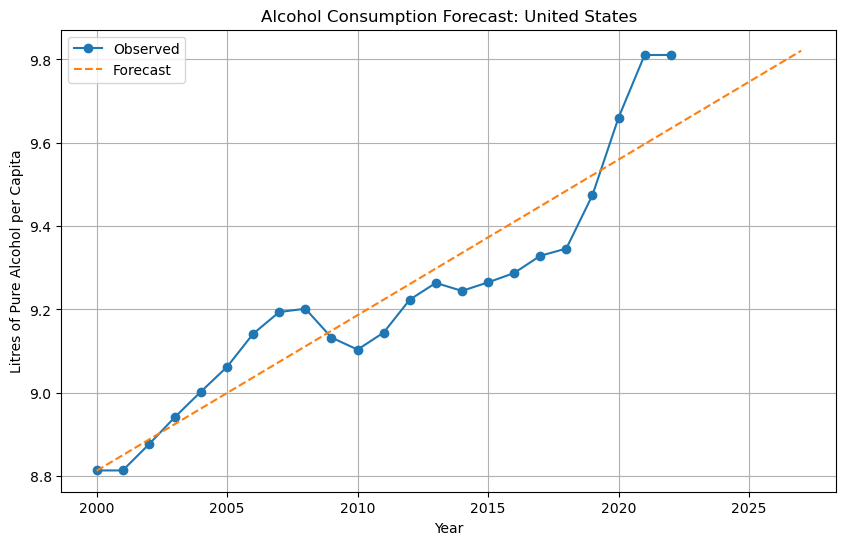

In [104]:
plt.figure(figsize=(10, 6))
plt.plot(country_data['Year'], country_data['Alcohol_Consumption'], marker='o', label='Observed')
plt.plot(future_years, forecast_values, linestyle='--', label='Forecast')
plt.title(f'Alcohol Consumption Forecast: {country_name}')
plt.xlabel('Year')
plt.ylabel('Litres of Pure Alcohol per Capita')
plt.legend()
plt.grid(True)
plt.savefig('alc_con_forecast.png', bbox_inches='tight')
plt.show()

## 7. Key Findings

In [106]:
# Countries with highest 2022 consumption

top_2022 = df[df['Year'] == 2022].sort_values('Alcohol_Consumption', ascending=False).head(10)
top_2022[['Country', 'Alcohol_Consumption']]

,Country,Alcohol_Consumption
3881,Romania,17.062368
2692,Georgia,15.538821
2852,Latvia,14.725691
4034,"Moldova, Republic of",14.128274
3827,Czechia,13.683375
4031,Lithuania,12.184915
3518,Namibia,11.993195
1685,Poland,11.917516
2834,Austria,11.849393
3339,Bulgaria,11.541503


In [107]:
# Countries with biggest decrease from 2000 to 2022

bottom_10_change = trend_compare.sort_values('Increase', ascending=True).head(10)
bottom_10_change[['Increase']]

Year,Increase
Country,
Burkina Faso,-10.018117
"Venezuela, Bolivarian Republic of",-5.901042
Ireland,-4.242714
Russian Federation,-3.509773
Belgium,-3.463774
Montenegro,-3.463298
France,-3.361441
Ukraine,-2.941896
Hungary,-2.704385


### world map visualization

In [109]:
import plotly.express as px

In [110]:
df_2022 = df[df['Year'] == 2022].copy()
df_2022.head()

,Country,Year,Alcohol_Consumption
22,Cameroon,2022,7.966839
77,Grenada,2022,7.768674
87,Cambodia,2022,5.398220
117,Afghanistan,2022,0.007942
164,Algeria,2022,0.455062


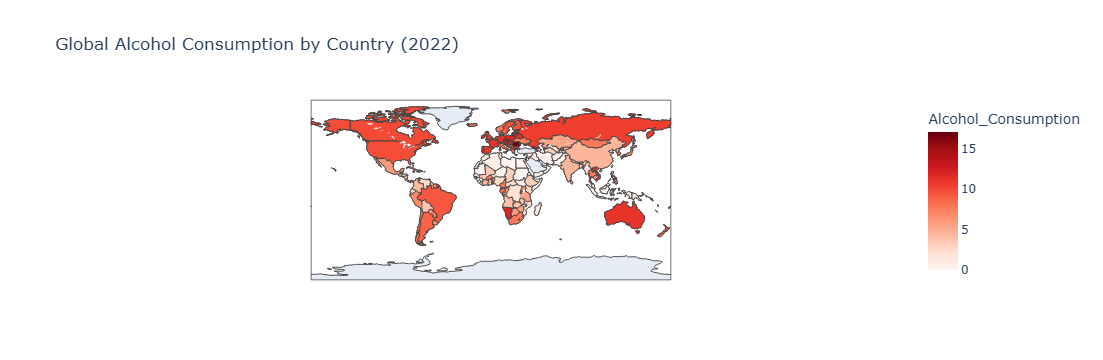

In [111]:
fig = px.choropleth(
    df_2022,
    locations="Country",
    locationmode="country names",
    color="Alcohol_Consumption",
    hover_name="Country",
    color_continuous_scale="Reds",
    title="Global Alcohol Consumption by Country (2022)"
)

fig.show()